# SIR ABM Model with Network

First, import our dependencies with `using`

In [ ]:
using AlgebraicRewriting
using AlgebraicABMs
using StateCharts
using Catlab
using DataMigrations


ENV["JULIA_DEBUG"] = "AlgebraicABMs"; 

## Model Schema

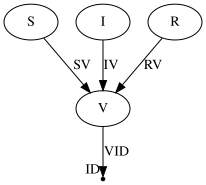

In [18]:
@present schema_statechart(FreeSchema) begin
    (S,I,R,V)::Ob
    SV::Hom(S,V)
    IV::Hom(I,V)
    RV::Hom(R,V)

    ID::AttrType
    VID::Attr(V,ID)
end
to_graphviz(schema_statechart; prog="dot")

## Schema of Incorporating Network

In [ ]:
@present schema_model <: SchSymmetricReflexiveGraph begin
    (S,I,R)::Ob
    SV::Hom(S,V)
    IV::Hom(I,V)
    RV::Hom(R,V)

    ID::AttrType
    VID::Attr(V,ID)
end;

to_graphviz(schema_model; prog="dot")
@acset_type SIRStateChart(schema_statechart, index=[:src,:tgt]){Symbol}
@acset_type SIRModelStaticNet(schema_model, index=[:src,:tgt]){Symbol} <: AbstractSymmetricReflexiveGraph
const ySIRStateChart = yoneda_cache(SIRStateChart; clear=false)

## Create the Rewrite Rules

## Rewrite Rule from S to I

In [ ]:
inf_l = @acset_colim ySIRStateChart begin
    s::S
    i::I
end

inf_m = @acset_colim ySIRStateChart begin
    v::V
    i::I
end

inf_r = @acset_colim ySIRStateChart begin
    i1::I
    i2::I  
end

## Rewrite Rule from I to R

In [ ]:
rec_l = @acset_colim ySIRStateChart begin i::I end
rec_m = @acset_colim ySIRStateChart begin v::V end
rec_r = @acset_colim ySIRStateChart begin r::R end

## Create the Migration

In [ ]:
const migrate_rule = @migration schema_model schema_statechart begin
    V => V; 
    ID=>ID; VID => VID
    S => S; SV => SV
    I => I; IV => IV
    R => R; RV => RV

    E => @product begin
        p1::V
        p2::V
    end
    src => p1
    tgt => p2
    inv => begin
        p1 => p2
        p2 => p1
    end
end

using `Migrate()` to migrate rules, but currently `Migrate()` seems not works for this example

```
Net = Migrate(schema_statechart,SIRStateChart,schema_model,SIRModelStaticNet; delta=false)
rules = [ABMRule(:inf, inf, ContinuousHazard(1.0)), ABMRule(:red, rec, ContinuousHazard(12.0))]
migrated_rules=Net(ABM(rules))
```

## Migrate L, I, and R in each rewrite rule to the model schema

In [ ]:
inf_l_net = migrate(SIRModelStaticNet,inf_l,migrate_rule)
inf_m_net = migrate(SIRModelStaticNet,inf_m,migrate_rule)
inf_r_net = migrate(SIRModelStaticNet,inf_r,migrate_rule)

rec_l_net = migrate(SIRModelStaticNet,rec_l,migrate_rule)
rec_m_net = migrate(SIRModelStaticNet,rec_m,migrate_rule)
rec_r_net = migrate(SIRModelStaticNet,rec_r,migrate_rule)

## Create the Rewrite Rule

In [ ]:
inf_net = Rule(only(homomorphisms(inf_m_net,inf_l_net;monic=[:V])),only(homomorphisms(inf_m_net,inf_r_net;monic=[:V],initial=(I=[2],))))
rec_net = Rule(only(homomorphisms(rec_m_net,rec_l_net;monic=[:V])),only(homomorphisms(rec_m_net,rec_r_net;monic=[:V])))

## Create the ABMRule in the Model Schema

In [ ]:
inf_net_rule = ABMRule(:inf_net, inf_net, ContinuousHazard(15.0))
rec_net_rule = ABMRule(:rec_net, rec_net, ContinuousHazard(20.0))

rules = [inf_net_rule,rec_net_rule]
abm = ABM(rules)

## Define the Network

In [26]:
totalPopulation = 20
average_connections = 2
p_random_connect = 0.9
network = smallworldNetWork(Int(totalPopulation), average_connections, p_random_connect);

## Define the Initial State and Parameters

In [ ]:
init = SIRModelStaticNet()
copy_parts!(init, network) # set the vertices' ID
set_subpart!(init, 1:Int(totalPopulation), :VID, map(id->:V*Symbol(id),1:Int(totalPopulation)))

add_parts!(init,:S,Int(totalPopulation-2),SV=3:totalPopulation)
add_parts!(init,:I,2,IV=1:2)


## Run the model

In [ ]:
res = run!(abm, init; maxtime=11);

## Visualize the Results

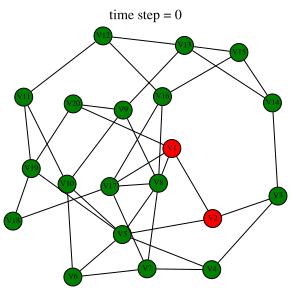

In [29]:
colorgroups = Dict(:S => "green",:I => "red",:R => "gray");

t = 0

StateCharts.Graph(res,t,colorgroups)

hist is a partial map: World_t <-< . -> World_(t+1) 

state of World_t

res.hist[t] |> left |> codom

res.hist[t] |> left |> dom

res.hist[t] |> right |> codom

res.hist[t] |> right |> dom